# **CARGAR LIBRERIAS**

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

**CARGAR DATOS**

In [ ]:
# Cargamos los datos
df = pd.read_excel("datos1.xlsx")
df.head(2)

,Muestra,Productos-Lote,Tiempo-Entrega,Defectuoso
0,1,19,19000,0
1,2,35,20000,0


In [13]:
X1 = 'Productos-Lote'
X2 = 'Tiempo-Entrega'
Y = 'Defectuoso'

# Arboles de decicion

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:

X = df[['Productos-Lote', 'Tiempo-Entrega']].values
y = df['Defectuoso'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


In [16]:
clasificador2 = DecisionTreeClassifier(criterion="entropy", random_state=0)
clasificador2.fit(X_train_raw, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [17]:
from sklearn.metrics import confusion_matrix
y_pred_tree = clasificador2.predict(X_test_raw)
cm_2 = confusion_matrix(y_test,y_pred_tree)
cm_2

array([[62,  6],
       [ 3, 29]])

In [18]:
score_t = clasificador2.score(X_test_raw,y_test)
score_t

0.91

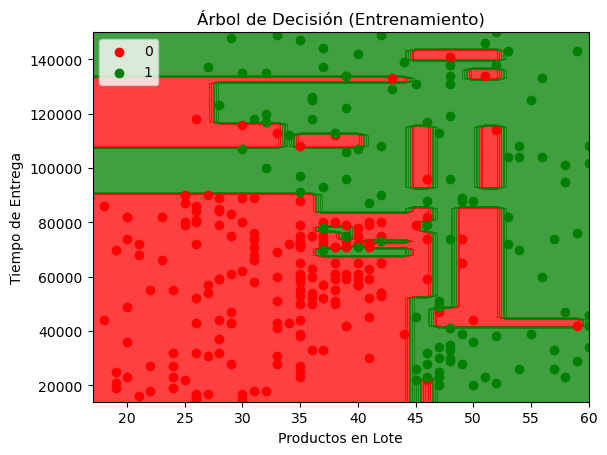

In [19]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_train_raw, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 1),
    np.arange(X_set[:, 1].min() - 1000, X_set[:, 1].max() + 1000, 1000)
)

plt.contourf(
    X1, X2,
    clasificador2.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], c='red', label='0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], c='green', label='1')

plt.title('Árbol de Decisión (Entrenamiento)')
plt.xlabel('Productos en Lote')
plt.ylabel('Tiempo de Entrega')
plt.legend()
plt.show()


# Conclucion

El arbol de decicion nos permite sgmentar los datos en diferentes grupos , en este caso el arlbol de decicion nos da un 91% de confianza, el cual se podria mejorar aumentando los datos y eliminando datos outliers.